# Machine Learning Models for Solar Power Forecasting (GBDT Family)

This notebook implements Gradient Boosted Decision Tree (GBDT) models for forecasting AC power output from solar inverters. It serves as a comparison against the statistical baseline (SARIMA) established in the previous notebook.

## Models:
- **XGBoost** (xgboost - Extreme Gradient Boosting)
- **GradientBoostingRegressor** (scikit-learn - Gradient Boosting Regressor )

## Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [ ]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML models
import xgboost as xgb

# Scikit-learn utilities
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Data Loading

In [18]:
# Load the dataset
DATA_PATH = '../../data/datasets/forecasting/ml_models_dataset.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Inverters: {df['inverter_id'].unique()}")
print(f"\nData types:")
print(df.dtypes)
df.head(10)

Dataset shape: (1788288, 79)
Date range: 2026-02-01 19:41:11.671261+00:00 to 2026-04-09 11:54:48.353354+00:00
Inverters: ['A0' 'A1' 'A2' 'A3' 'B0' 'B1' 'B2' 'B3' 'C0' 'C1' 'C2' 'C3' 'C4' 'C5']

Data types:
inverter_id                                          object
state                                                 int64
timestamp                               datetime64[ns, UTC]
inverter_temp_c                                     float64
ac_power_kw                                         float64
                                               ...         
poa_irradiance_wm2_rolling_mean_2095                float64
dc_to_ac_ratio                                      float64
power_per_healthy_string                            float64
temp_diff                                           float64
irradiance_temp_interaction                         float64
Length: 79, dtype: object


,inverter_id,state,timestamp,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,active_failures,healthy_strings,failed_strings,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,hour,day_of_week,day_of_month,month,quarter,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,ac_power_kw_lag_7,ac_power_kw_lag_21,ac_power_kw_lag_43,ac_power_kw_lag_87,ac_power_kw_lag_174,ac_power_kw_lag_523,ac_power_kw_lag_2095,ac_power_kw_lag_4190,ac_power_kw_lag_14665,poa_irradiance_wm2_lag_7,amb_temp_c_lag_7,poa_irradiance_wm2_lag_21,amb_temp_c_lag_21,poa_irradiance_wm2_lag_43,amb_temp_c_lag_43,poa_irradiance_wm2_lag_87,amb_temp_c_lag_87,poa_irradiance_wm2_lag_174,amb_temp_c_lag_174,poa_irradiance_wm2_lag_523,amb_temp_c_lag_523,poa_irradiance_wm2_lag_2095,amb_temp_c_lag_2095,poa_irradiance_wm2_lag_4190,amb_temp_c_lag_4190,poa_irradiance_wm2_lag_14665,amb_temp_c_lag_14665,ac_power_kw_rolling_mean_7,ac_power_kw_rolling_std_7,poa_irradiance_wm2_rolling_mean_7,ac_power_kw_rolling_mean_21,ac_power_kw_rolling_std_21,poa_irradiance_wm2_rolling_mean_21,ac_power_kw_rolling_mean_87,ac_power_kw_rolling_std_87,poa_irradiance_wm2_rolling_mean_87,ac_power_kw_rolling_mean_523,ac_power_kw_rolling_std_523,poa_irradiance_wm2_rolling_mean_523,ac_power_kw_rolling_mean_1047,ac_power_kw_rolling_std_1047,poa_irradiance_wm2_rolling_mean_1047,ac_power_kw_rolling_mean_2095,ac_power_kw_rolling_std_2095,poa_irradiance_wm2_rolling_mean_2095,dc_to_ac_ratio,power_per_healthy_string,temp_diff,irradiance_temp_interaction
0,A0,2,2026-02-01 19:41:11.671261+00:00,20.85,0.0,0.0,0.0,0.0,0.0,0,12,0,9.97,9.97,2.22,127.9,54.7,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
1,A0,2,2026-02-01 19:41:44.136330+00:00,19.28,0.0,0.0,0.0,0.0,0.0,0,12,0,10.68,10.68,2.14,126.4,55.0,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A0,2,2026-02-01 19:42:32.506975+00:00,19.59,0.0,0.0,0.0,0.0,0.0,0,12,0,10.02,10.02,2.19,125.5,54.4,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A0,2,2026-02-01 19:43:27.839696+00:00,19.25,0.0,0.0,0.0,0.0,0.0,0,12,0,10.03,10.03,2.19,129.0,53.8,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A0,2,2026-02-01 19:44:12.934204+00:00,19.80,0.0,0.0,0.0,0.0,0.0,0,12,0,10.74,10.74,2.32,131.3,52.2,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,A0,2,2026-02-01 19:45:01.168789+00:00,19.94,0.0,0.0,0.0,0.0,0.0,0,12,0,10.06,10.06,2.37,129.5,51.9,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,A0,2,2026-02-01 19:46:00.237302+00:00,19.39,0.0,0.0,0.0,0.0,0.0,0,12,0,10.08,10.08,2.27,129.7,53.3,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [19]:
# Basic statistics
print("Statistical Summary:")
print(df['ac_power_kw'].describe())

print(f"\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print(f"\nRecords per inverter:")
print(df.groupby('inverter_id').size())

Statistical Summary:
count    1.788288e+06
mean     3.341016e+01
std      3.861469e+01
min      0.000000e+00
25%      3.000000e-03
50%      3.000000e-03
75%      7.986100e+01
max      9.015700e+01
Name: ac_power_kw, dtype: float64

Missing values (top 10):
poa_irradiance_wm2_lag_14665    205310
amb_temp_c_lag_14665            205310
ac_power_kw_lag_14665           205310
ac_power_kw_lag_4190             58660
amb_temp_c_lag_4190              58660
poa_irradiance_wm2_lag_4190      58660
ac_power_kw_lag_2095             29330
poa_irradiance_wm2_lag_2095      29330
amb_temp_c_lag_2095              29330
poa_irradiance_wm2_lag_523        7322
dtype: int64

Records per inverter:
inverter_id
A0    127708
A1    127695
A2    127979
A3    127689
B0    127769
B1    127816
B2    127835
B3    127731
C0    127768
C1    127671
C2    127608
C3    127652
C4    127708
C5    127659
dtype: int64


In [20]:
# Select a single inverter for modeling (A0 as reference, same as baseline notebook)
INVERTER_ID = 'A0'

df_inverter = df[df['inverter_id'] == INVERTER_ID].copy()
df_inverter = df_inverter.set_index('timestamp').sort_index()

print(f"Selected inverter: {INVERTER_ID}")
print(f"Records: {len(df_inverter)}")
print(f"Date range: {df_inverter.index.min()} to {df_inverter.index.max()}")
df_inverter.head()

Selected inverter: A0
Records: 127708
Date range: 2026-02-01 19:41:11.671261+00:00 to 2026-04-09 11:50:40.416762+00:00


,inverter_id,state,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,active_failures,healthy_strings,failed_strings,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,hour,day_of_week,day_of_month,month,quarter,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,ac_power_kw_lag_7,ac_power_kw_lag_21,ac_power_kw_lag_43,ac_power_kw_lag_87,ac_power_kw_lag_174,ac_power_kw_lag_523,ac_power_kw_lag_2095,ac_power_kw_lag_4190,ac_power_kw_lag_14665,poa_irradiance_wm2_lag_7,amb_temp_c_lag_7,poa_irradiance_wm2_lag_21,amb_temp_c_lag_21,poa_irradiance_wm2_lag_43,amb_temp_c_lag_43,poa_irradiance_wm2_lag_87,amb_temp_c_lag_87,poa_irradiance_wm2_lag_174,amb_temp_c_lag_174,poa_irradiance_wm2_lag_523,amb_temp_c_lag_523,poa_irradiance_wm2_lag_2095,amb_temp_c_lag_2095,poa_irradiance_wm2_lag_4190,amb_temp_c_lag_4190,poa_irradiance_wm2_lag_14665,amb_temp_c_lag_14665,ac_power_kw_rolling_mean_7,ac_power_kw_rolling_std_7,poa_irradiance_wm2_rolling_mean_7,ac_power_kw_rolling_mean_21,ac_power_kw_rolling_std_21,poa_irradiance_wm2_rolling_mean_21,ac_power_kw_rolling_mean_87,ac_power_kw_rolling_std_87,poa_irradiance_wm2_rolling_mean_87,ac_power_kw_rolling_mean_523,ac_power_kw_rolling_std_523,poa_irradiance_wm2_rolling_mean_523,ac_power_kw_rolling_mean_1047,ac_power_kw_rolling_std_1047,poa_irradiance_wm2_rolling_mean_1047,ac_power_kw_rolling_mean_2095,ac_power_kw_rolling_std_2095,poa_irradiance_wm2_rolling_mean_2095,dc_to_ac_ratio,power_per_healthy_string,temp_diff,irradiance_temp_interaction
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-02-01 19:41:11.671261+00:00,A0,2,20.85,0.0,0.0,0.0,0.0,0.0,0,12,0,9.97,9.97,2.22,127.9,54.7,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2026-02-01 19:41:44.136330+00:00,A0,2,19.28,0.0,0.0,0.0,0.0,0.0,0,12,0,10.68,10.68,2.14,126.4,55.0,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-01 19:42:32.506975+00:00,A0,2,19.59,0.0,0.0,0.0,0.0,0.0,0,12,0,10.02,10.02,2.19,125.5,54.4,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-01 19:43:27.839696+00:00,A0,2,19.25,0.0,0.0,0.0,0.0,0.0,0,12,0,10.03,10.03,2.19,129.0,53.8,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-01 19:44:12.934204+00:00,A0,2,19.80,0.0,0.0,0.0,0.0,0.0,0,12,0,10.74,10.74,2.32,131.3,52.2,0.0,19,6,1,2,1,1,-0.965926,0.258819,-0.781831,0.62349,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


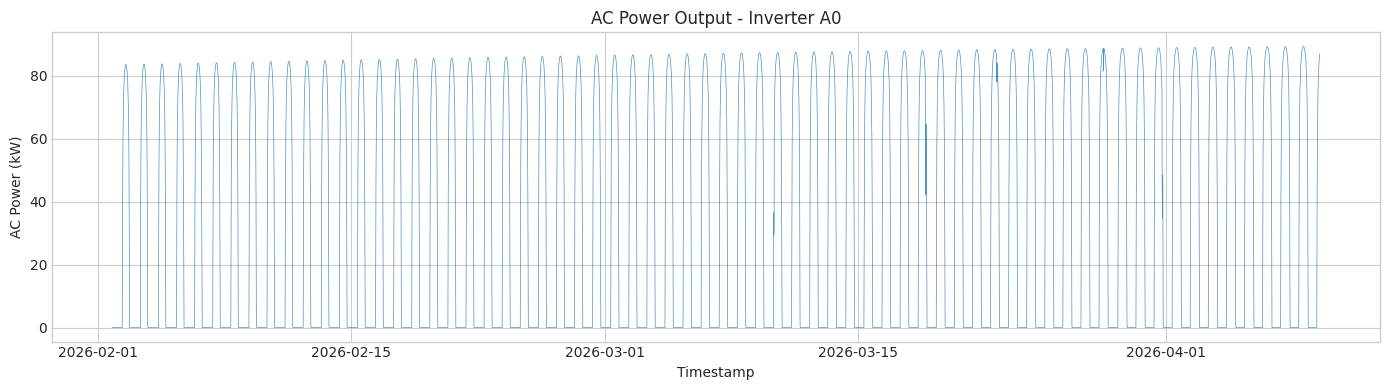

In [21]:
# Visualize the full time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_inverter.index, df_inverter['ac_power_kw'], linewidth=0.5, alpha=0.8)
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'AC Power Output - Inverter {INVERTER_ID}')
plt.tight_layout()
plt.show()

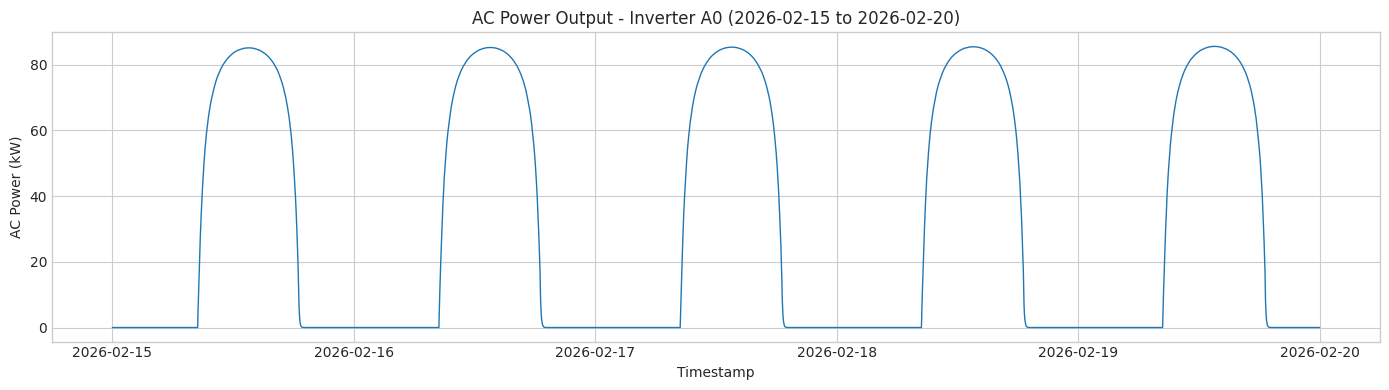

In [22]:
# Visualize a few days to see daily pattern
sample_start = '2026-02-15'
sample_end = '2026-02-20'

fig, ax = plt.subplots(figsize=(14, 4))
mask = (df_inverter.index >= sample_start) & (df_inverter.index < sample_end)
ax.plot(df_inverter.loc[mask].index, df_inverter.loc[mask]['ac_power_kw'], linewidth=1)
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'AC Power Output - Inverter {INVERTER_ID} ({sample_start} to {sample_end})')
plt.tight_layout()
plt.show()

## Data Preprocessing

For ML models, we'll:
1. Drop identifier columns (`inverter_id`, `state`)
2. **Remove data leakage columns** — features measured at the same timestamp as the target (`ac_power_kw`) that would not be available when forecasting future values
3. Keep only lag features, rolling statistics, and temporal features (known in advance)
4. Handle missing values from lag features (drop rows with NaN)
5. Create train/test split (80/20 chronological)

In [23]:
# Drop non-feature columns and data leakage columns
TARGET = 'ac_power_kw'

# Identifier columns (not features)
ID_COLS = ['inverter_id', 'state']

# DATA LEAKAGE: columns measured at the SAME timestamp as the target.
# These would NOT be available when predicting future ac_power_kw.
LEAKAGE_COLS = [
    # Inverter electrical readings at prediction time
    'inverter_temp_c', 'ac_freq_hz', 'dc_power_kw', 'dc_voltage_v', 'dc_current_a',
    # System status at prediction time
    'active_failures', 'healthy_strings', 'failed_strings',
    # Weather/sensor readings at prediction time (not forecasted)
    'amb_temp_c', 'module_temp_c', 'wind_speed_ms', 'wind_dir_deg',
    'humidity_percent', 'poa_irradiance_wm2',
    # Derived from simultaneous measurements
    'dc_to_ac_ratio', 'power_per_healthy_string', 'temp_diff',
    'irradiance_temp_interaction',
]

# Add to leakege all columns that contain "lag" and "rolling"
lag_cols = [c for c in df_inverter.columns if 'lag' in c]
rolling_cols = [c for c in df_inverter.columns if 'rolling' in c]
LEAKAGE_COLS += lag_cols + rolling_cols

DROP_COLS = ID_COLS + LEAKAGE_COLS
drop_existing = [c for c in DROP_COLS if c in df_inverter.columns]
df_model = df_inverter.drop(columns=drop_existing)

print(f"Removed {len(drop_existing)} columns (identifiers + leakage):")
for col in drop_existing:
    tag = "ID" if col in ID_COLS else "LEAKAGE"
    print(f"  [{tag}] {col}")

# Drop rows with NaN values (from lag features at the beginning of the series)
rows_before = len(df_model)
df_model = df_model.dropna()
rows_after = len(df_model)
print(f"\nDropped {rows_before - rows_after} rows with NaN values ({(rows_before - rows_after)/rows_before*100:.1f}%)")
print(f"Remaining rows: {rows_after}")

# Define features and target
feature_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feature_cols]
y = df_model[TARGET]

print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nKept features (no leakage):")
for col in feature_cols:
    print(f"  - {col}")

Removed 65 columns (identifiers + leakage):
  [ID] inverter_id
  [ID] state
  [LEAKAGE] inverter_temp_c
  [LEAKAGE] ac_freq_hz
  [LEAKAGE] dc_power_kw
  [LEAKAGE] dc_voltage_v
  [LEAKAGE] dc_current_a
  [LEAKAGE] active_failures
  [LEAKAGE] healthy_strings
  [LEAKAGE] failed_strings
  [LEAKAGE] amb_temp_c
  [LEAKAGE] module_temp_c
  [LEAKAGE] wind_speed_ms
  [LEAKAGE] wind_dir_deg
  [LEAKAGE] humidity_percent
  [LEAKAGE] poa_irradiance_wm2
  [LEAKAGE] dc_to_ac_ratio
  [LEAKAGE] power_per_healthy_string
  [LEAKAGE] temp_diff
  [LEAKAGE] irradiance_temp_interaction
  [LEAKAGE] ac_power_kw_lag_7
  [LEAKAGE] ac_power_kw_lag_21
  [LEAKAGE] ac_power_kw_lag_43
  [LEAKAGE] ac_power_kw_lag_87
  [LEAKAGE] ac_power_kw_lag_174
  [LEAKAGE] ac_power_kw_lag_523
  [LEAKAGE] ac_power_kw_lag_2095
  [LEAKAGE] ac_power_kw_lag_4190
  [LEAKAGE] ac_power_kw_lag_14665
  [LEAKAGE] poa_irradiance_wm2_lag_7
  [LEAKAGE] amb_temp_c_lag_7
  [LEAKAGE] poa_irradiance_wm2_lag_21
  [LEAKAGE] amb_temp_c_lag_21
  [LEAKAG

Training set: 102166 samples (2026-02-01 19:41:11.671261+00:00 to 2026-03-27 04:34:02.628289+00:00)
Test set:     25542 samples (2026-03-27 04:34:53.062708+00:00 to 2026-04-09 11:50:40.416762+00:00)


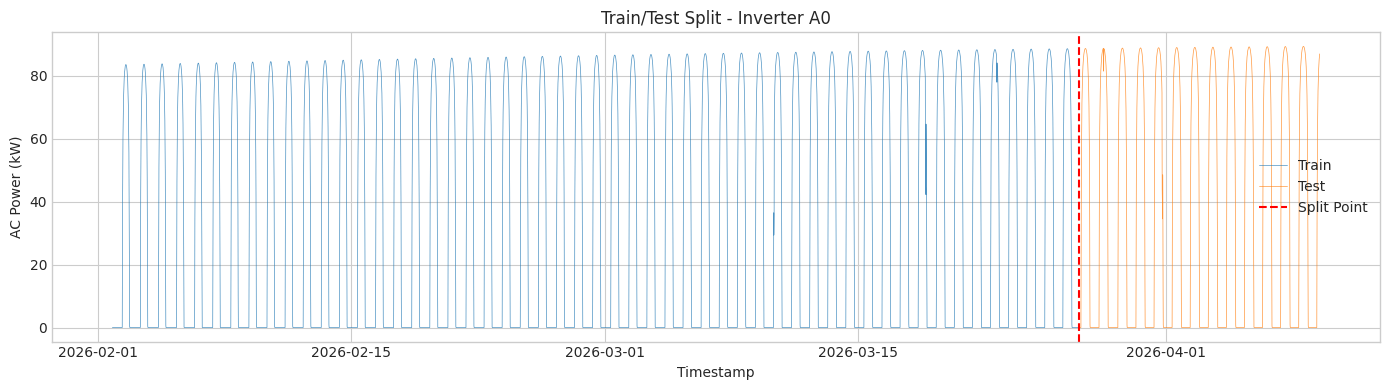

In [24]:
# Train/Test split (80/20 chronological)
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training set: {len(X_train)} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test set:     {len(X_test)} samples ({X_test.index.min()} to {X_test.index.max()})")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train.values, label='Train', alpha=0.8, linewidth=0.5)
ax.plot(y_test.index, y_test.values, label='Test', alpha=0.8, linewidth=0.5)
ax.axvline(x=y_test.index[0], color='red', linestyle='--', label='Split Point')
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title(f'Train/Test Split - Inverter {INVERTER_ID}')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Helper functions for evaluation
def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, and MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE - avoid division by zero
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def plot_forecast(y_true, y_pred, title, hours_to_show=168):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    # Full test period
    axes[0].plot(y_true.index, y_true.values, label='Actual', alpha=0.7, linewidth=0.5)
    axes[0].plot(y_true.index, y_pred, label='Forecast', alpha=0.7, linewidth=0.5)
    axes[0].set_title(f'{title} - Full Test Period')
    axes[0].set_ylabel('AC Power (kW)')
    axes[0].legend()

    # First N samples detail (approximate hours based on ~1 sample/30s)
    n_samples = min(hours_to_show * 120, len(y_true))  # ~120 samples/hour
    axes[1].plot(y_true.index[:n_samples], y_true.values[:n_samples], label='Actual', alpha=0.8)
    axes[1].plot(y_true.index[:n_samples], y_pred[:n_samples], label='Forecast', alpha=0.8)
    axes[1].set_title(f'{title} - First ~{hours_to_show} Hours')
    axes[1].set_xlabel('Timestamp')
    axes[1].set_ylabel('AC Power (kW)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title, top_n=20):
    """Plot top N feature importances"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.get_feature_importance()

    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    feat_imp = feat_imp.tail(top_n)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind='barh', ax=ax)
    ax.set_title(f'{title} - Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Store results for comparison
results = {}

## 1. GradientBoostingRegressor

In [26]:
# GradientBoostingRegressor model
print("Training GradientBoostingRegressor model...")

gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
)

gbr_model.fit(
    X_train, y_train
)

# Predict
gbr_pred = np.clip(gbr_model.predict(X_test), 0, None)

# Evaluate
results['GradientBoostingRegressor'] = calculate_metrics(y_test.values, gbr_pred)
print(f"\nGradientBoostingRegressor Results:")
print(f"  MAE:  {results['GradientBoostingRegressor']['MAE']:.4f} kW")
print(f"  RMSE: {results['GradientBoostingRegressor']['RMSE']:.4f} kW")
print(f"  MAPE: {results['GradientBoostingRegressor']['MAPE']:.2f}%")

Training GradientBoostingRegressor model...

GradientBoostingRegressor Results:
  MAE:  6.7892 kW
  RMSE: 15.8362 kW
  MAPE: 17086.37%


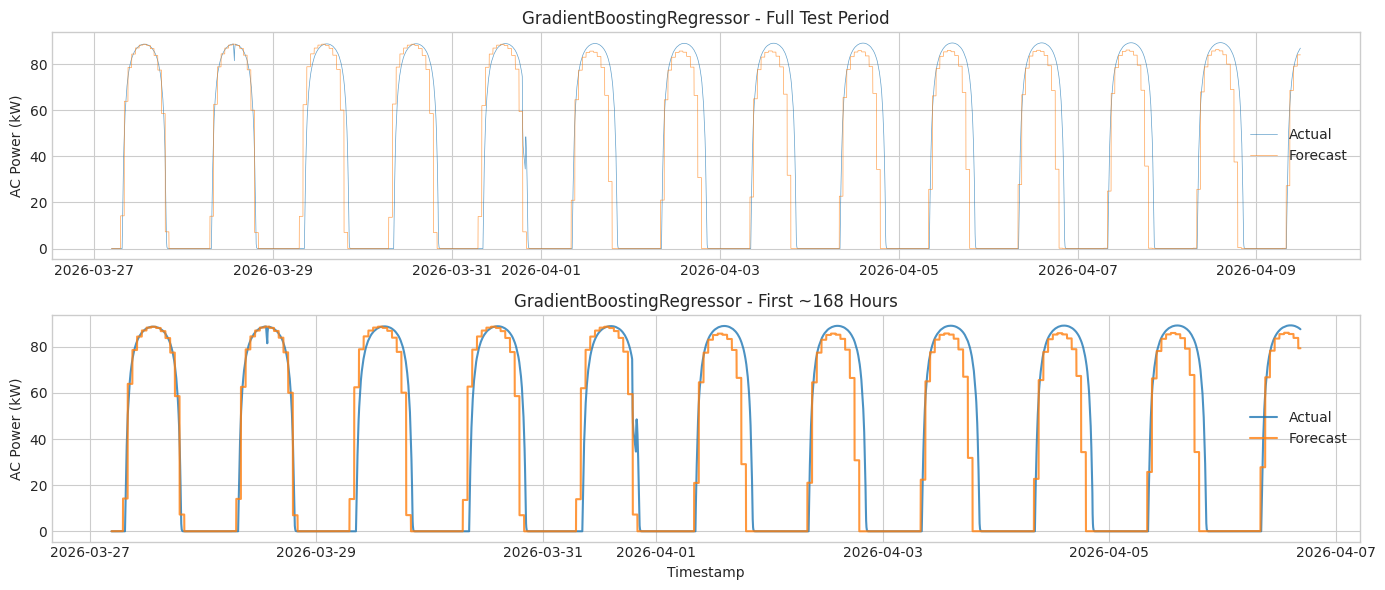

In [27]:
# Visualize GradientBoostingRegressor forecast
plot_forecast(y_test, gbr_pred, 'GradientBoostingRegressor')

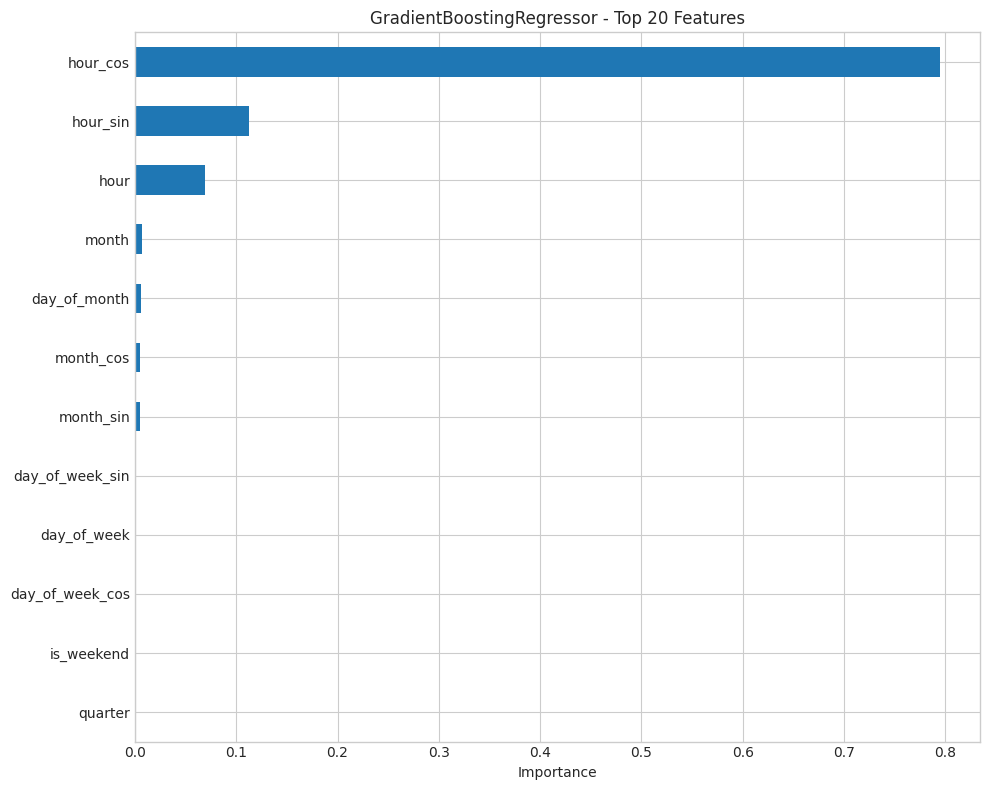

In [28]:
# GradientBoostingRegressor feature importance
plot_feature_importance(gbr_model, feature_cols, 'GradientBoostingRegressor')

## 2. XGBoost

In [29]:
# XGBoost model
print("Training XGBoost model...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

# Predict
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)

# Evaluate
results['XGBoost'] = calculate_metrics(y_test.values, xgb_pred)
print(f"\nXGBoost Results:")
print(f"  MAE:  {results['XGBoost']['MAE']:.4f} kW")
print(f"  RMSE: {results['XGBoost']['RMSE']:.4f} kW")
print(f"  MAPE: {results['XGBoost']['MAPE']:.2f}%")

Training XGBoost model...
[0]	validation_0-rmse:39.10972
[100]	validation_0-rmse:15.61635
[114]	validation_0-rmse:15.64147

XGBoost Results:
  MAE:  7.6057 kW
  RMSE: 15.5476 kW
  MAPE: 37599.45%


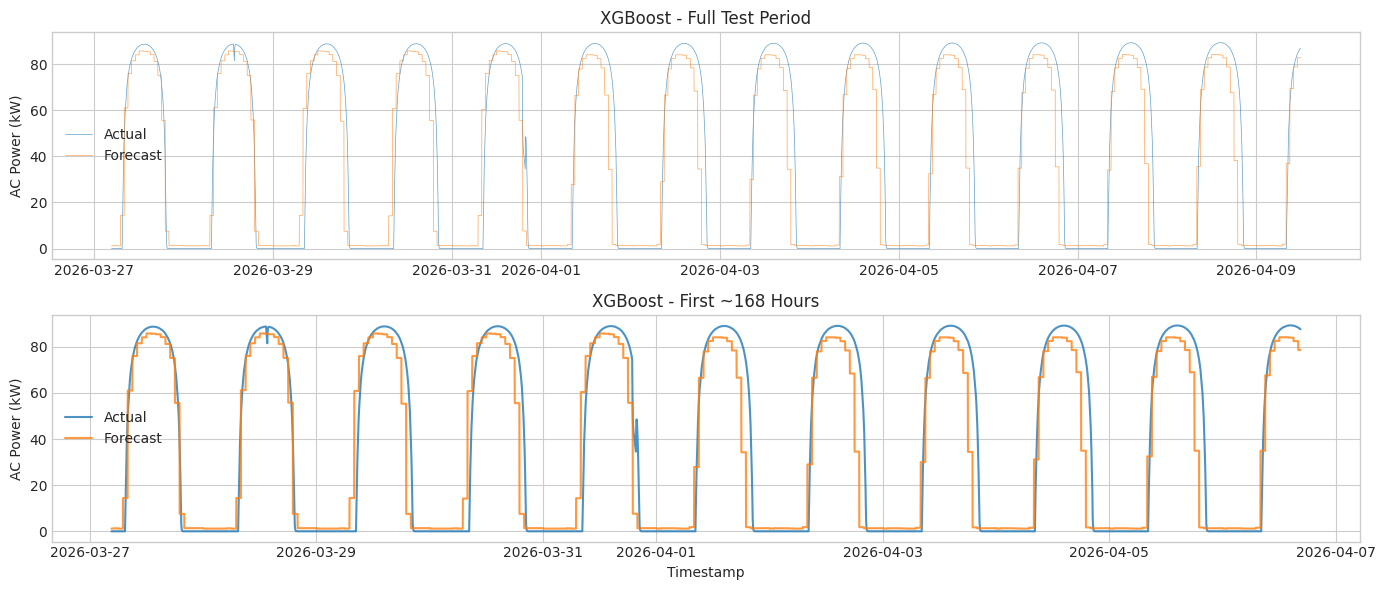

In [30]:
# Visualize XGBoost forecast
plot_forecast(y_test, xgb_pred, 'XGBoost')

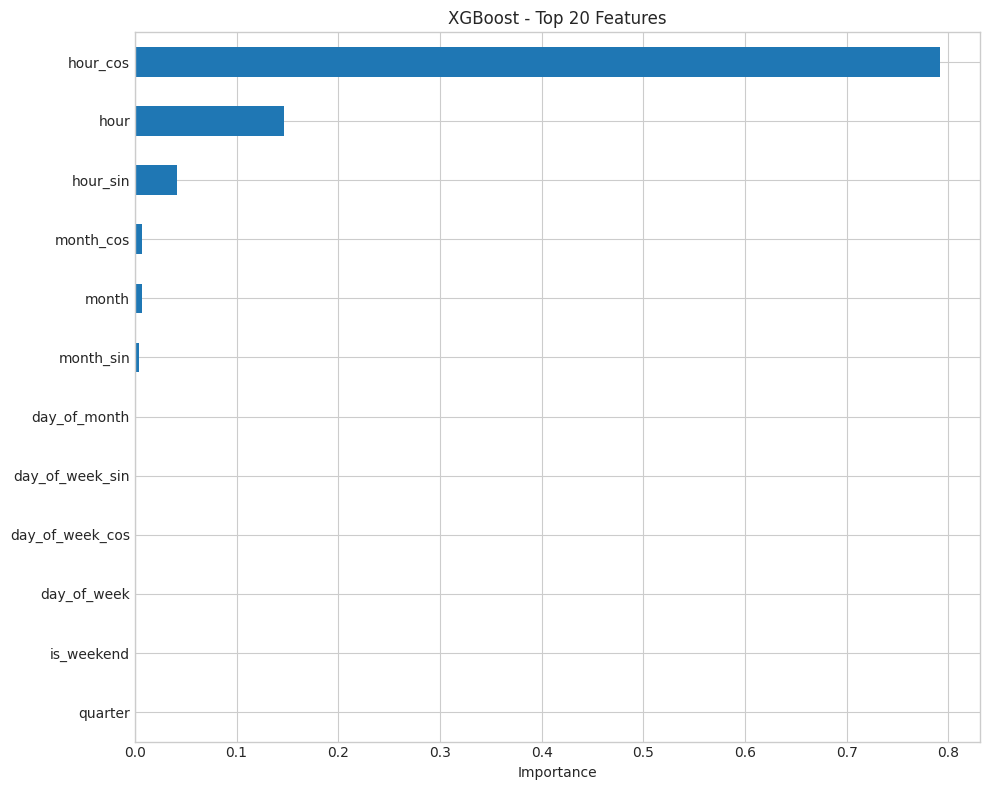

In [31]:
# XGBoost feature importance
plot_feature_importance(xgb_model, feature_cols, 'XGBoost')

## Model Comparison

Compare all three GBDT models side-by-side on the evaluation metrics.

In [32]:
# Results comparison table
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df = results_df.round(4)
print("=" * 60)
print("MODEL COMPARISON - GBDT Family")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

# Highlight best model per metric
print("\nBest model per metric:")
for metric in ['MAE', 'RMSE', 'MAPE']:
    best_model = results_df[metric].idxmin()
    best_value = results_df[metric].min()
    print(f"  {metric}: {best_model} ({best_value:.4f})")

results_df

MODEL COMPARISON - GBDT Family
                              MAE     RMSE        MAPE
Model                                                 
GradientBoostingRegressor  6.7892  15.8362  17086.3741
XGBoost                    7.6057  15.5476  37599.4480

Best model per metric:
  MAE: GradientBoostingRegressor (6.7892)
  RMSE: XGBoost (15.5476)
  MAPE: GradientBoostingRegressor (17086.3741)


,MAE,RMSE,MAPE
Model,,,
GradientBoostingRegressor,6.7892,15.8362,17086.3741
XGBoost,7.6057,15.5476,37599.4480


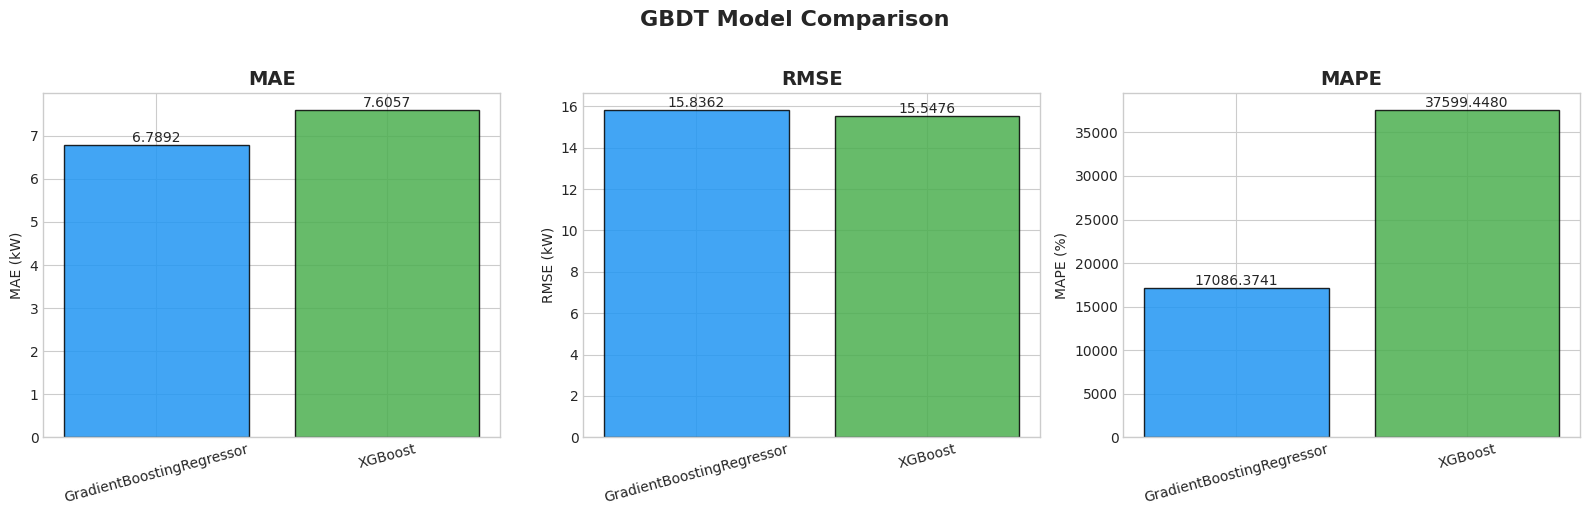

In [33]:
# Visual comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'MAPE']
colors = ['#2196F3', '#4CAF50']

for i, metric in enumerate(metrics):
    values = results_df[metric]
    bars = axes[i].bar(values.index, values.values, color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(f'{metric} ({"kW" if metric != "MAPE" else "%"})')
    axes[i].tick_params(axis='x', rotation=15)

    # Annotate bars
    for bar, val in zip(bars, values.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('GBDT Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

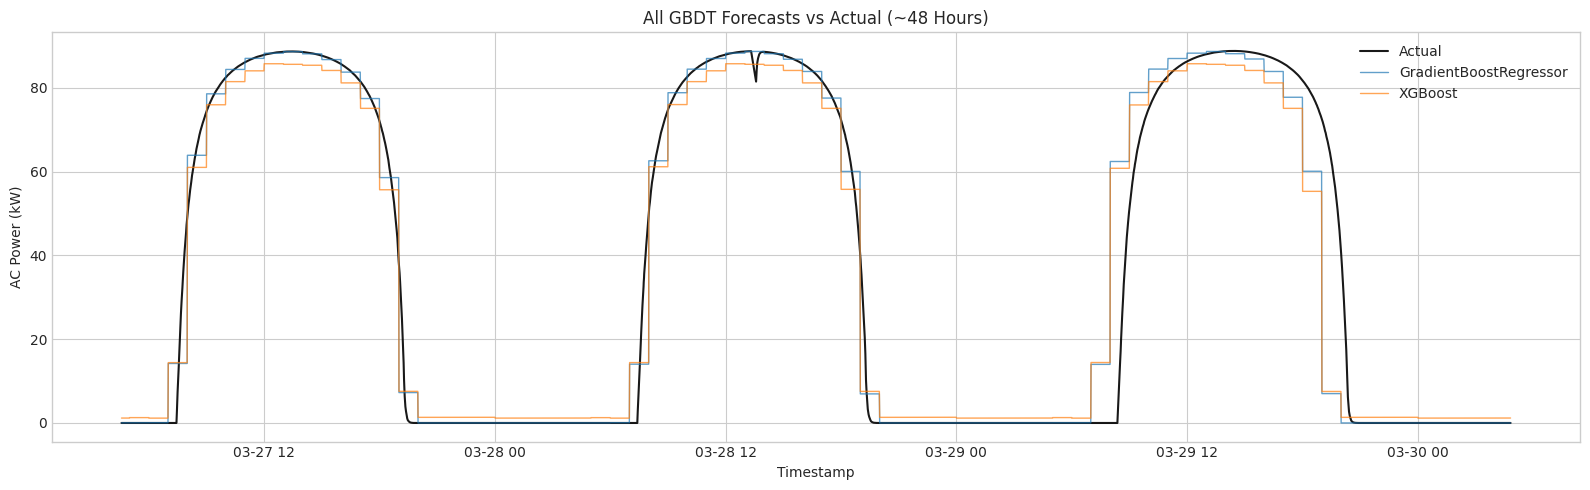

In [34]:
# Overlay all forecasts on a zoomed-in window
n_samples = 120 * 48  # ~2 days of data

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index[:n_samples], y_test.values[:n_samples], label='Actual', color='black', linewidth=1.5, alpha=0.9)
ax.plot(y_test.index[:n_samples], gbr_pred[:n_samples], label='GradientBoostRegressor', alpha=0.7, linewidth=1)
ax.plot(y_test.index[:n_samples], xgb_pred[:n_samples], label='XGBoost', alpha=0.7, linewidth=1)
ax.set_xlabel('Timestamp')
ax.set_ylabel('AC Power (kW)')
ax.set_title('All GBDT Forecasts vs Actual (~48 Hours)')
ax.legend()
plt.tight_layout()
plt.show()

## Error Analysis

Analyze prediction errors across different conditions to understand model behavior.

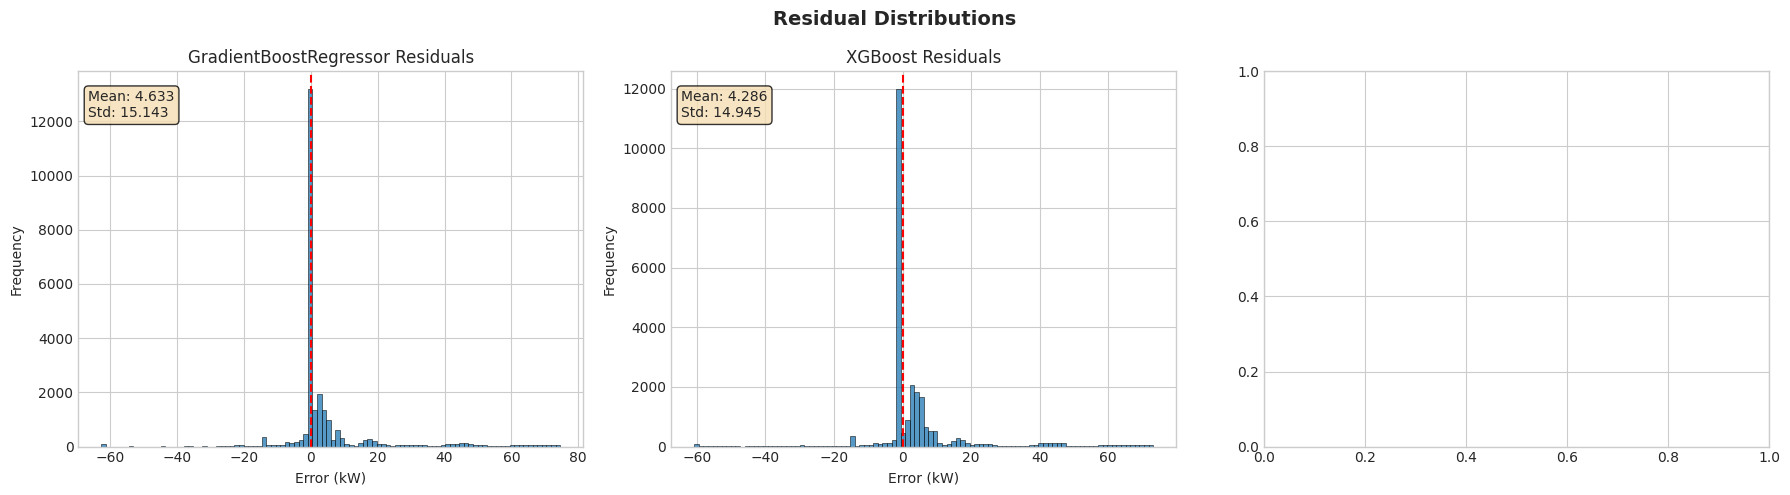

In [35]:
# Residual analysis for all models
predictions = {
    'GradientBoostRegressor': gbr_pred,
    'XGBoost': xgb_pred,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, pred) in enumerate(predictions.items()):
    residuals = y_test.values - pred
    axes[i].hist(residuals, bins=100, alpha=0.75, edgecolor='black', linewidth=0.5)
    axes[i].axvline(x=0, color='red', linestyle='--')
    axes[i].set_title(f'{name} Residuals')
    axes[i].set_xlabel('Error (kW)')
    axes[i].set_ylabel('Frequency')
    axes[i].text(0.02, 0.95, f'Mean: {residuals.mean():.3f}\nStd: {residuals.std():.3f}',
                 transform=axes[i].transAxes, va='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Residual Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

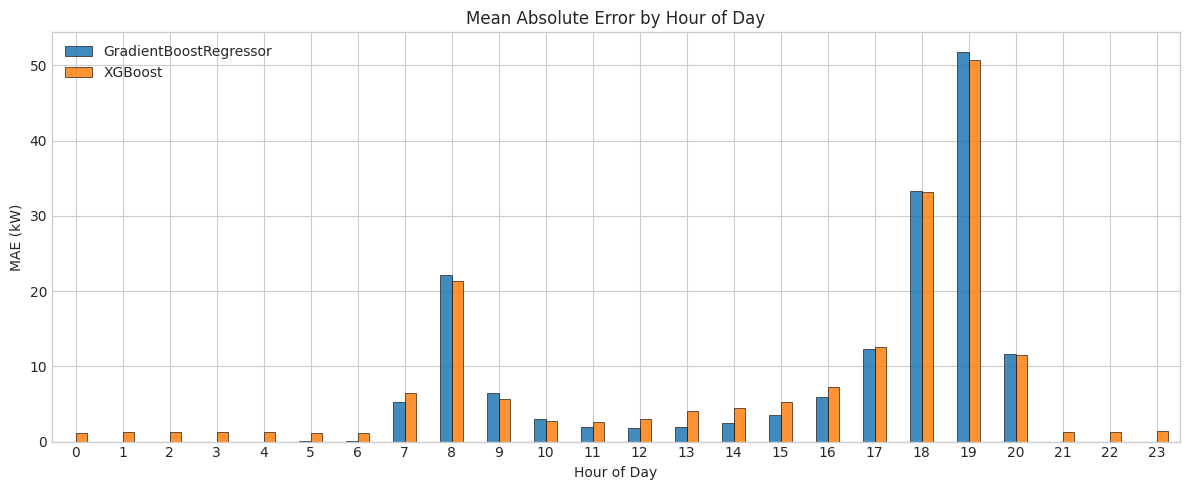

In [36]:
# Error by hour of day - understand when models struggle most
error_df = pd.DataFrame({
    'hour': X_test['hour'].values,
    'actual': y_test.values,
    'XGBoost_error': np.abs(y_test.values - xgb_pred),
    'GradientBoostRegressor_error': np.abs(y_test.values - gbr_pred),
})

hourly_mae = error_df.groupby('hour')[['GradientBoostRegressor_error', 'XGBoost_error']].mean()

fig, ax = plt.subplots(figsize=(12, 5))
hourly_mae.plot(kind='bar', ax=ax, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('MAE (kW)')
ax.set_title('Mean Absolute Error by Hour of Day')
ax.legend(['GradientBoostRegressor', 'XGBoost'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Time Series Cross-Validation

Evaluate model robustness using `TimeSeriesSplit` to ensure results are not dependent on a single train/test partition. We use the best-performing model for CV.

In [38]:
# Time Series Cross-Validation
# Identify best model from single split results
best_model_name = results_df['MAE'].idxmin()
print(f"Running Time Series CV with the best model: {best_model_name}")

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {'MAE': [], 'RMSE': [], 'MAPE': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]

    # Train the best model type
    if best_model_name == 'XGBoost':
        cv_model = xgb.XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, early_stopping_rounds=30,
        )
        cv_model.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)], verbose=0)
    elif best_model_name == 'GradientBoostingRegressor':
        cv_model = GradientBoostingRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, random_state=42,
        )
        cv_model.fit(X_cv_train, y_cv_train)

    cv_pred = np.clip(cv_model.predict(X_cv_val), 0, None)
    fold_metrics = calculate_metrics(y_cv_val.values, cv_pred)

    for metric in cv_results:
        cv_results[metric].append(fold_metrics[metric])

    print(f"  Fold {fold+1}: MAE={fold_metrics['MAE']:.4f}, RMSE={fold_metrics['RMSE']:.4f}, MAPE={fold_metrics['MAPE']:.2f}%")

print(f"\nCross-Validation Summary ({best_model_name}):")
for metric in cv_results:
    values = cv_results[metric]
    print(f"  {metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Running Time Series CV with the best model: GradientBoostingRegressor
  Fold 1: MAE=2.3518, RMSE=6.2190, MAPE=6194.78%
  Fold 2: MAE=3.8505, RMSE=9.5949, MAPE=3680.64%
  Fold 3: MAE=2.0359, RMSE=5.4180, MAPE=233.99%
  Fold 4: MAE=2.3100, RMSE=6.1288, MAPE=7413.21%
  Fold 5: MAE=7.4719, RMSE=16.7812, MAPE=8016.21%

Cross-Validation Summary (GradientBoostingRegressor):
  MAE: 3.6040 ± 2.0358
  RMSE: 8.8284 ± 4.2323
  MAPE: 5107.7659 ± 2854.6833
